In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('house_price.csv')
df

,area,bedrooms,bathrooms,city,price
0,1200.0,2.0,2.0,Pokhara,4500000
1,1500.0,NaN,3.0,Kathmandu,6500000
2,1800.0,3.0,2.0,Chitwan,5200000
3,2200.0,4.0,3.0,Pokhara,7500000
4,950.0,2.0,1.0,Butwal,3200000
5,1300.0,3.0,2.0,Kathmandu,5800000
6,1700.0,3.0,NaN,Pokhara,6100000
7,2000.0,4.0,3.0,Chitwan,6900000
8,1100.0,2.0,2.0,Butwal,3900000
9,2500.0,5.0,4.0,Kathmandu,9800000


In [29]:
import math
median_bedrooms = math.floor(df['bedrooms'].median())
median_bathrooms = math.floor(df['bathrooms'].median())
median_area = math.floor(df['area'].median())

In [30]:
df['bedrooms'] = df.bedrooms.fillna(median_bedrooms)
df['bathrooms'] = df.bathrooms.fillna(median_bathrooms)
df['area'] = df.area.fillna(median_area)

In [31]:
dummy = pd.get_dummies(df['city'],dtype=int)

medium = pd.concat([df,dummy],axis='columns')
print(medium.columns)

Index(['area', 'bedrooms', 'bathrooms', 'city', 'price', 'Butwal', 'Chitwan',
       'Kathmandu', 'Pokhara'],
      dtype='str')


In [32]:
final_price = medium.drop(medium[['city','Butwal']],axis='columns')

In [33]:
final_price

,area,bedrooms,bathrooms,price,Chitwan,Kathmandu,Pokhara
0,1200.0,2.0,2.0,4500000,0,0,1
1,1500.0,3.0,3.0,6500000,0,1,0
2,1800.0,3.0,2.0,5200000,1,0,0
3,2200.0,4.0,3.0,7500000,0,0,1
4,950.0,2.0,1.0,3200000,0,0,0
5,1300.0,3.0,2.0,5800000,0,1,0
6,1700.0,3.0,2.0,6100000,0,0,1
7,2000.0,4.0,3.0,6900000,1,0,0
8,1100.0,2.0,2.0,3900000,0,0,0
9,2500.0,5.0,4.0,9800000,0,1,0


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
model = LinearRegression()

In [42]:
X = final_price.drop(final_price[['price']],axis='columns')
y = final_price.price

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4)

In [44]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1772.36,302397.57,606781.77, 4048.95,960544.24,635598.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['area','bedrooms','bathrooms','Chitwan','Kathmandu','Pokhara']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.389e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [50]:
y_pred = model.predict(X_test)

In [61]:
score = model.score(X_train,y_train)

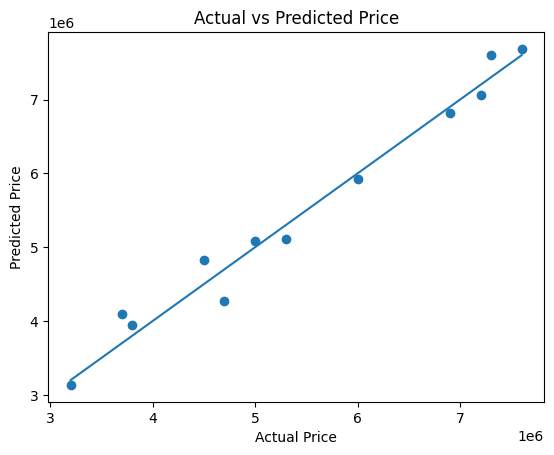

In [64]:
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.savefig("actual_vs_predicted.png")

In [63]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

print("R2 score:",score)
print("MSE:", mean_squared_error(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))

R2 score: 0.9853450126481041
MSE: 52931421557.88848
MAE: 192492.07962817664
